In [9]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, K_lines=None, S0=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    
    if S0 is not None:
        plt.axvline(S0, color='orange', linewidth=1.2,
                    linestyle='--', label=f'S0={S0}')
    
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Prima neta pagada : $3.76
Ganancia máxima   : $16.24  (si ST =680)
Pérdida máxima    : $-3.76
Break-even inf.   : $663.76  |  sup.: $696.24


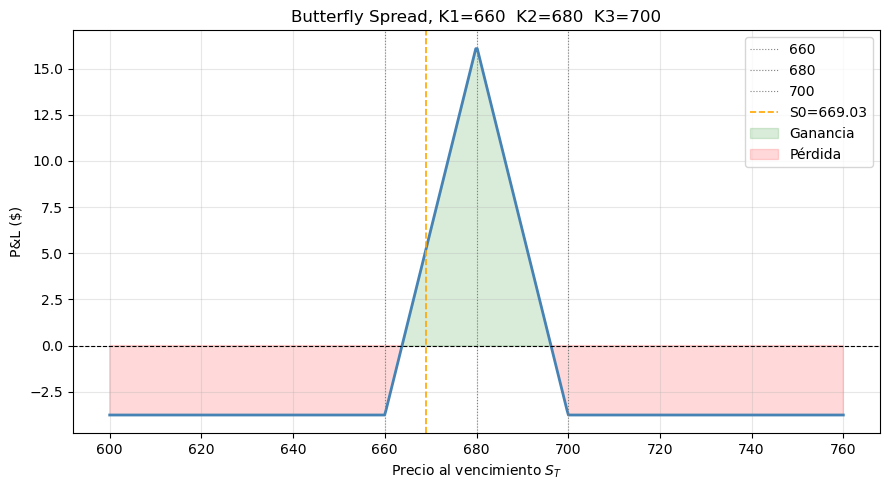

In [11]:
import numpy as np
import matplotlib.pyplot as plt

S_range = np.linspace(600, 760, 500)
S0 = 669.03

K1, K2, K3 = 660, 680, 700
C1, C2, C3 = 18.00, 9.37, 4.50

legs_butterfly = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3, 'prima': C3, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_butterfly)
prima_neta = C1 - 2*C2 + C3

print(f"Prima neta pagada : ${prima_neta:.2f}")
print(f"Ganancia máxima   : ${(K2-K1)-prima_neta:.2f}  (si ST ={K2})")
print(f"Pérdida máxima    : ${-prima_neta:.2f}")
print(f"Break-even inf.   : ${K1+prima_neta:.2f}  |  sup.: ${K3-prima_neta:.2f}")

graficar_estrategia(S_range, pnl, f'Butterfly Spread, K1={K1}  K2={K2}  K3={K3}',
                    S0=S0, K_lines=[(K1,f'{K1}'),(K2,f'{K2}'),(K3,f'{K3}')])

Prima cobrada     : $9.60  (ganancia máxima)
Pérdida máxima    : $10.40
Zona de ganancia  : [660,700]


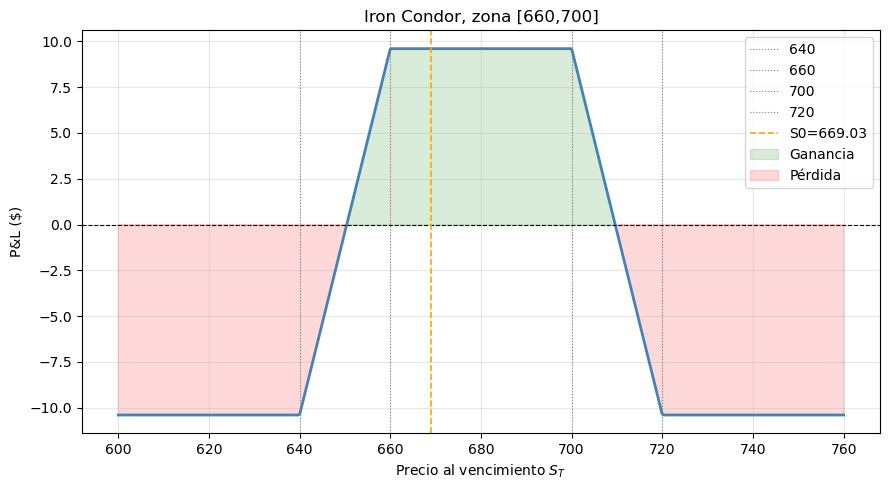

In [12]:
K_pl, K_ps = 640, 660     # put leg: long K_pl, short K_ps
K_cs, K_cl = 700, 720     # call leg: short K_cs, long K_cl
P_l, P_s   = 5.50, 11.20
C_s, C_l   = 6.80, 2.90

legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_condor)
prima_cobrada = (P_s - P_l) + (C_s - C_l)
perdida_max   = (K_ps - K_pl) - prima_cobrada

print(f"Prima cobrada     : ${prima_cobrada:.2f}  (ganancia máxima)")
print(f"Pérdida máxima    : ${perdida_max:.2f}")
print(f"Zona de ganancia  : [{K_ps},{K_cs}]")

graficar_estrategia(S_range, pnl,
                    f'Iron Condor, zona [{K_ps},{K_cs}]', S0=S0,
                    K_lines=[(K_pl,f'{K_pl}'),(K_ps,f'{K_ps}'),
                             (K_cs,f'{K_cs}'),(K_cl,f'{K_cl}')])

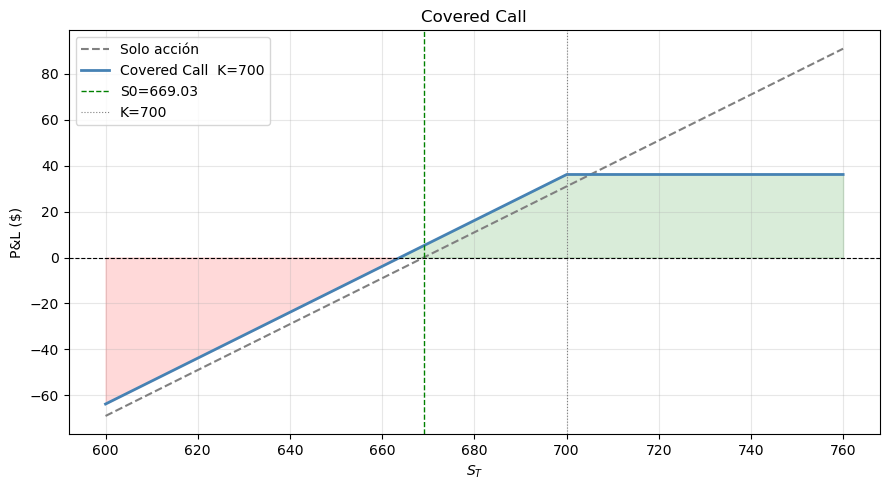

Ganancia máxima : $36.17  (si ST ≥700)
Break-even      : $663.83


In [13]:
K_cc, C_cc = 700, 5.20
pnl_accion  = S_range - S0
pnl_covered = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,  color='gray',      linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_covered, color='steelblue', linewidth=2,
         label=f'Covered Call  K={K_cc}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0}')
plt.axvline(K_cc, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_cc}')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered<0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Covered Call'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Ganancia máxima : ${K_cc - S0 + C_cc:.2f}  (si ST ≥{K_cc})")
print(f"Break-even      : ${S0 - C_cc:.2f}")

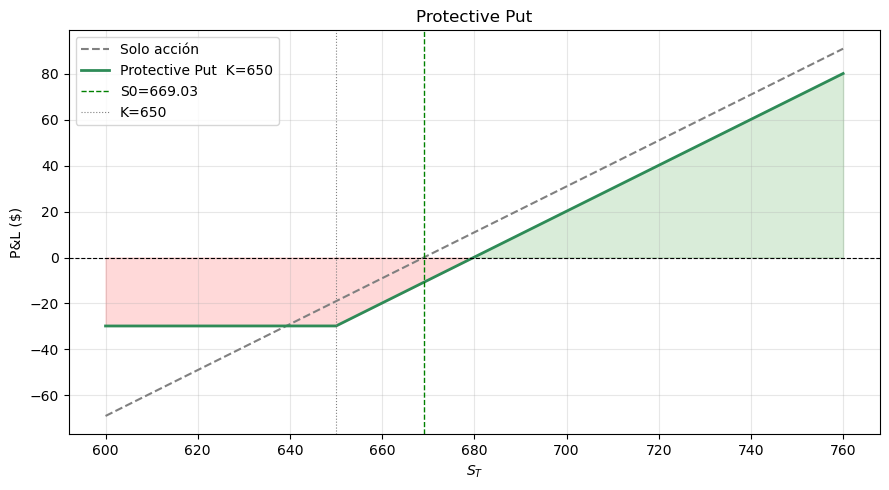

Pérdida máxima : $-29.83  (si ST ≤650)
Break-even     : $679.83


In [14]:
K_pp, P_pp = 650, 10.80
pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)

plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,     color='gray',    linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_protective, color='seagreen', linewidth=2,
         label=f'Protective Put  K={K_pp}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0}')
plt.axvline(K_pp, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_pp}')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective<0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Protective Put'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Pérdida máxima : ${-(S0 - K_pp + P_pp):.2f}  (si ST ≤{K_pp})")
print(f"Break-even     : ${S0 + P_pp:.2f}")

### Actividad

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from datetime import date

In [17]:
ticker  = 'SPY'
expiry  = '2026-04-17'
 
spy  = yf.Ticker(ticker)
S0   = spy.history(period='1d')['Close'].iloc[-1]
print(f"Precio actual de SPY (S0): ${S0:.2f}")

calls_df = spy.option_chain(expiry).calls
puts_df  = spy.option_chain(expiry).puts
 
calls_df['mid'] = (calls_df['bid'] + calls_df['ask']) / 2
puts_df['mid']  = (puts_df['bid']  + puts_df['ask'])  / 2
 
print(f"\nVencimiento: {expiry}")
print(f"Strikes calls disponibles cerca de S0:")
print(calls_df[['strike','bid','ask','mid','impliedVolatility']]
      .loc[(calls_df['strike'] >= S0*0.93) & (calls_df['strike'] <= S0*1.07)]
      .to_string(index=False))
 
print(f"\nStrikes puts disponibles cerca de S0:")
print(puts_df[['strike','bid','ask','mid','impliedVolatility']]
      .loc[(puts_df['strike'] >= S0*0.93) & (puts_df['strike'] <= S0*1.07)]
      .to_string(index=False))

Precio actual de SPY (S0): $694.46

Vencimiento: 2026-04-17
Strikes calls disponibles cerca de S0:
 strike   bid   ask    mid  impliedVolatility
  646.0 48.22 48.63 48.425           0.387213
  647.0 47.23 47.64 47.435           0.383307
  648.0 46.23 46.64 46.435           0.376471
  649.0 45.24 45.65 45.445           0.372077
  650.0 44.39 44.56 44.475           0.332038
  651.0 43.25 43.66 43.455           0.360846
  652.0 42.26 42.67 42.465           0.356452
  653.0 41.26 41.67 41.465           0.349128
  654.0 40.27 40.68 40.475           0.344245
  655.0 39.42 39.59 39.505           0.310065
  656.0 38.43 38.60 38.515           0.306648
  657.0 37.30 37.71 37.505           0.329597
  658.0 36.31 36.72 36.515           0.324226
  659.0 35.32 35.73 35.525           0.318854
  660.0 34.47 34.64 34.555           0.290046
  661.0 33.34 33.75 33.545           0.307624
  662.0 32.35 32.76 32.555           0.301765
  663.0 31.37 31.78 31.575           0.297370
  664.0 30.38 30.79 30.585 

In [18]:
def get_mid(df, strike):
    row = df[df['strike'] == strike]
    if row.empty:
        # Tomar el más cercano
        idx = (df['strike'] - strike).abs().idxmin()
        row = df.loc[[idx]]
    return round(row['mid'].values[0], 2), round(row['strike'].values[0], 2)

In [19]:
S0_round = round(S0 / 5) * 5
 

K1_bf = S0_round - 10
K2_bf = S0_round
K3_bf = S0_round + 10
 
C1, K1_bf = get_mid(calls_df, K1_bf)
C2, K2_bf = get_mid(calls_df, K2_bf)
C3, K3_bf = get_mid(calls_df, K3_bf)
 
print("=== Strikes seleccionados ===")
print(f"Butterfly  — K1={K1_bf} (C={C1}), K2={K2_bf} (C={C2}), K3={K3_bf} (C={C3})")
 

K_pl_ic = S0_round - 30;  K_ps_ic = S0_round - 15
K_cs_ic = S0_round + 15;  K_cl_ic = S0_round + 30
 
P_l, K_pl_ic = get_mid(puts_df,  K_pl_ic)
P_s, K_ps_ic = get_mid(puts_df,  K_ps_ic)
C_s_ic, K_cs_ic = get_mid(calls_df, K_cs_ic)
C_l_ic, K_cl_ic = get_mid(calls_df, K_cl_ic)
 
print(f"Iron Condor — K_pl={K_pl_ic}(P={P_l}), K_ps={K_ps_ic}(P={P_s}), "
      f"K_cs={K_cs_ic}(C={C_s_ic}), K_cl={K_cl_ic}(C={C_l_ic})")
 

K_cc = S0_round + 15
C_cc, K_cc = get_mid(calls_df, K_cc)
print(f"Covered Call — K={K_cc}, prima={C_cc}")
 

K_pp = S0_round - 15
P_pp, K_pp = get_mid(puts_df, K_pp)
print(f"Protective Put — K={K_pp}, prima={P_pp}")

=== Strikes seleccionados ===
Butterfly  — K1=685.0 (C=10.74), K2=695.0 (C=3.3), K3=705.0 (C=0.32)
Iron Condor — K_pl=665.0(P=0.26), K_ps=680.0(P=0.84), K_cs=710.0(C=0.11), K_cl=725.0(C=0.02)
Covered Call — K=710.0, prima=0.11
Protective Put — K=680.0, prima=0.84



=== BUTTERFLY SPREAD ===
Prima neta pagada : $4.46
Ganancia máxima   : $5.54  (si ST = 695.0)
Pérdida máxima    : $-4.46
Break-even inf.   : $689.46  |  sup.: $700.54


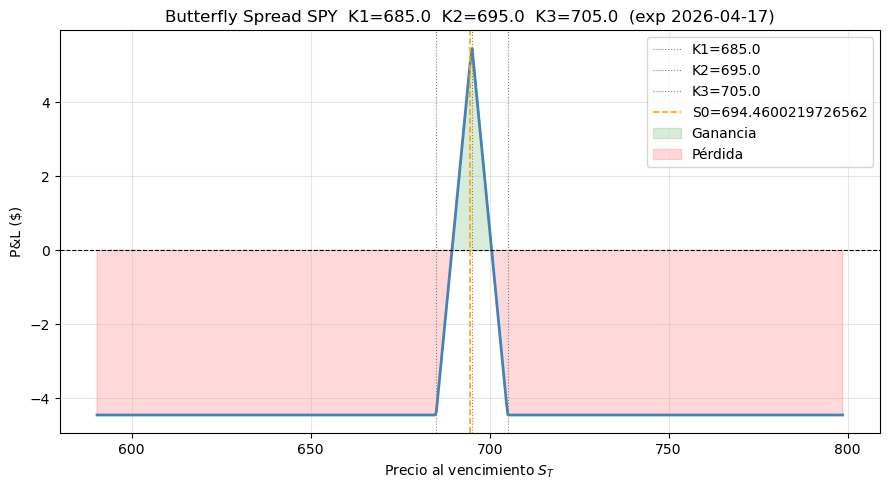

In [20]:
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 500)
 
 

# 1. BUTTERFLY SPREAD

legs_butterfly = [
    {'tipo': 'call', 'K': K1_bf, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2_bf, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3_bf, 'prima': C3, 'posicion': +1},
]
pnl_bf      = payoff_estrategia(S_range, legs_butterfly)
prima_neta_bf = C1 - 2*C2 + C3
 
print("\n=== BUTTERFLY SPREAD ===")
print(f"Prima neta pagada : ${prima_neta_bf:.2f}")
print(f"Ganancia máxima   : ${(K2_bf - K1_bf) - prima_neta_bf:.2f}  (si ST = {K2_bf})")
print(f"Pérdida máxima    : ${-prima_neta_bf:.2f}")
print(f"Break-even inf.   : ${K1_bf + prima_neta_bf:.2f}  |  sup.: ${K3_bf - prima_neta_bf:.2f}")
 
graficar_estrategia(
    S_range, pnl_bf,
    f'Butterfly Spread SPY  K1={K1_bf}  K2={K2_bf}  K3={K3_bf}  (exp {expiry})',
    S0=S0,
    K_lines=[(K1_bf, f'K1={K1_bf}'), (K2_bf, f'K2={K2_bf}'), (K3_bf, f'K3={K3_bf}')]
)


=== IRON CONDOR ===
Prima cobrada  (ganancia máx) : $0.67
Pérdida máxima                : $14.33
Zona de ganancia              : [680.0, 710.0]
Break-even inf.               : $679.33  |  sup.: $710.67


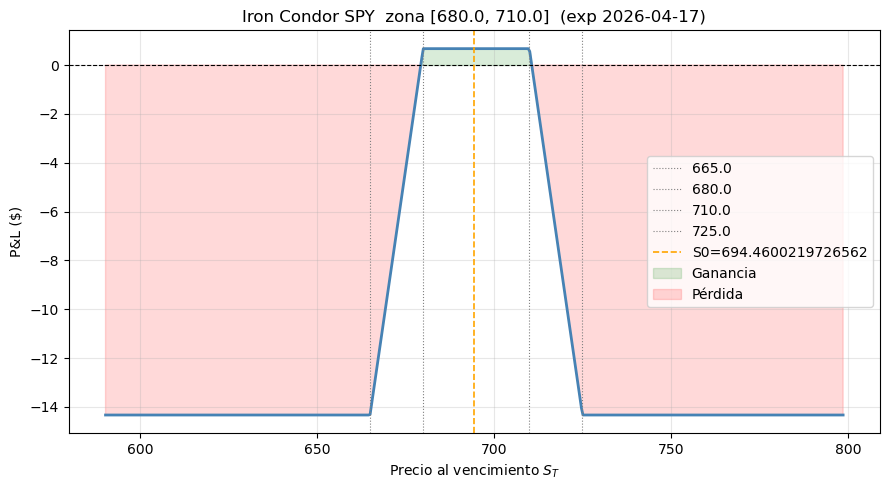

In [21]:
# 2. IRON CONDOR

legs_condor = [
    {'tipo': 'put',  'K': K_pl_ic, 'prima': P_l,    'posicion': +1},
    {'tipo': 'put',  'K': K_ps_ic, 'prima': P_s,    'posicion': -1},
    {'tipo': 'call', 'K': K_cs_ic, 'prima': C_s_ic, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl_ic, 'prima': C_l_ic, 'posicion': +1},
]
pnl_ic         = payoff_estrategia(S_range, legs_condor)
prima_cobrada_ic = (P_s - P_l) + (C_s_ic - C_l_ic)
perdida_max_ic   = (K_ps_ic - K_pl_ic) - prima_cobrada_ic
 
print("\n=== IRON CONDOR ===")
print(f"Prima cobrada  (ganancia máx) : ${prima_cobrada_ic:.2f}")
print(f"Pérdida máxima                : ${perdida_max_ic:.2f}")
print(f"Zona de ganancia              : [{K_ps_ic}, {K_cs_ic}]")
print(f"Break-even inf.               : ${K_ps_ic - prima_cobrada_ic:.2f}  "
      f"|  sup.: ${K_cs_ic + prima_cobrada_ic:.2f}")
 
graficar_estrategia(
    S_range, pnl_ic,
    f'Iron Condor SPY  zona [{K_ps_ic}, {K_cs_ic}]  (exp {expiry})',
    S0=S0,
    K_lines=[(K_pl_ic, f'{K_pl_ic}'), (K_ps_ic, f'{K_ps_ic}'),
             (K_cs_ic, f'{K_cs_ic}'), (K_cl_ic, f'{K_cl_ic}')]
)

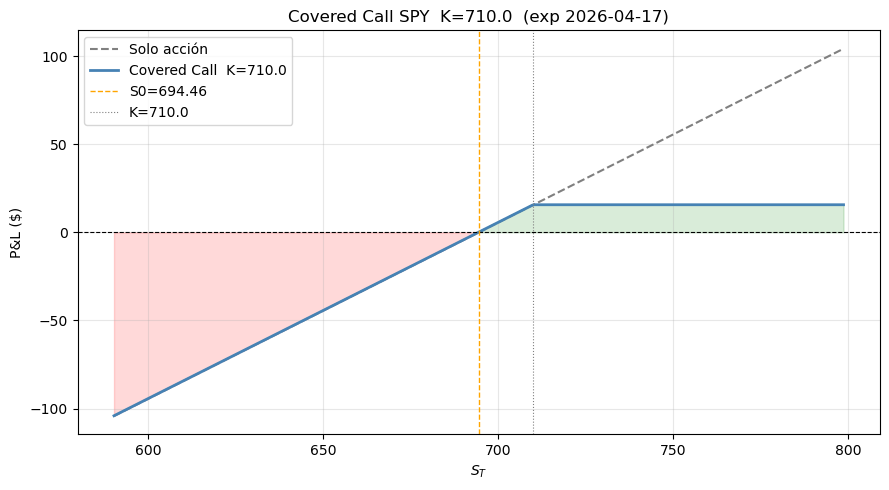


=== COVERED CALL ===
Ganancia máxima : $15.65  (si ST ≥ 710.0)
Break-even      : $694.35
Pérdida máxima  : ilimitada a la baja (amortiguada por la prima 0.11)


In [22]:
# 3. COVERED CALL

pnl_accion   = S_range - S0
pnl_covered  = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)
 
plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,  color='gray',      linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_covered, color='steelblue', linewidth=2,
         label=f'Covered Call  K={K_cc}')
plt.axhline(0,   color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,  color='orange', linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
plt.axvline(K_cc,color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_cc}')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered > 0),
                 alpha=0.15, color='green')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered < 0),
                 alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title(f'Covered Call SPY  K={K_cc}  (exp {expiry})')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
 
print("\n=== COVERED CALL ===")
print(f"Ganancia máxima : ${K_cc - S0 + C_cc:.2f}  (si ST ≥ {K_cc})")
print(f"Break-even      : ${S0 - C_cc:.2f}")
print(f"Pérdida máxima  : ilimitada a la baja (amortiguada por la prima {C_cc})")

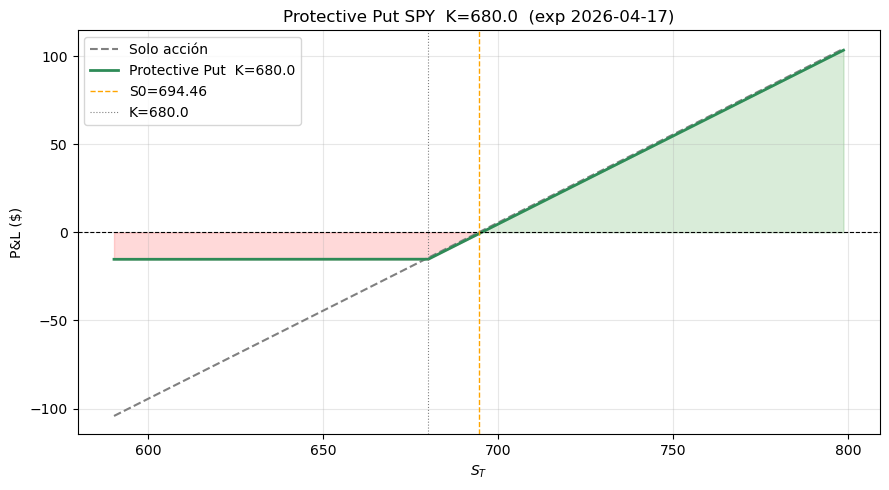


=== PROTECTIVE PUT ===
Pérdida máxima : $-15.30  (si ST ≤ 680.0)
Break-even     : $695.30
Ganancia máx   : ilimitada al alza (reducida por la prima 0.84)


In [23]:
# 4. PROTECTIVE PUT

pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)
 
plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,     color='gray',    linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_protective, color='seagreen', linewidth=2,
         label=f'Protective Put  K={K_pp}')
plt.axhline(0,   color='black',  linewidth=0.8, linestyle='--')
plt.axvline(S0,  color='orange', linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
plt.axvline(K_pp,color='gray',   linewidth=0.8, linestyle=':', label=f'K={K_pp}')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective > 0),
                 alpha=0.15, color='green')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective < 0),
                 alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title(f'Protective Put SPY  K={K_pp}  (exp {expiry})')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
 
print("\n=== PROTECTIVE PUT ===")
print(f"Pérdida máxima : ${-(S0 - K_pp + P_pp):.2f}  (si ST ≤ {K_pp})")
print(f"Break-even     : ${S0 + P_pp:.2f}")
print(f"Ganancia máx   : ilimitada al alza (reducida por la prima {P_pp})")

In [24]:
resumen = pd.DataFrame({
    'Estrategia':      ['Butterfly Spread', 'Iron Condor', 'Covered Call', 'Protective Put'],
    'Prima neta':      [f'Pagada ${prima_neta_bf:.2f}',
                        f'Cobrada ${prima_cobrada_ic:.2f}',
                        f'Cobrada ${C_cc:.2f}',
                        f'Pagada ${P_pp:.2f}'],
    'Ganancia máxima': [f'${(K2_bf-K1_bf)-prima_neta_bf:.2f}  (ST={K2_bf})',
                        f'${prima_cobrada_ic:.2f}  (ST∈[{K_ps_ic},{K_cs_ic}])',
                        f'${K_cc-S0+C_cc:.2f}  (ST≥{K_cc})',
                        'Ilimitada al alza'],
    'Pérdida máxima':  [f'${-prima_neta_bf:.2f}',
                        f'${perdida_max_ic:.2f}',
                        f'Ilimitada a la baja',
                        f'${-(S0-K_pp+P_pp):.2f}  (ST≤{K_pp})'],
    'Break-even(s)':   [f'${K1_bf+prima_neta_bf:.2f} | ${K3_bf-prima_neta_bf:.2f}',
                        f'${K_ps_ic-prima_cobrada_ic:.2f} | ${K_cs_ic+prima_cobrada_ic:.2f}',
                        f'${S0-C_cc:.2f}',
                        f'${S0+P_pp:.2f}'],
})
 
print("\n" + "="*80)
print("TABLA RESUMEN — Estrategias Neutrales SPY  (exp 2026-04-17)")
print("="*80)
print(resumen.to_string(index=False))


TABLA RESUMEN — Estrategias Neutrales SPY  (exp 2026-04-17)
      Estrategia    Prima neta           Ganancia máxima      Pérdida máxima     Break-even(s)
Butterfly Spread  Pagada $4.46         $5.54  (ST=695.0)              $-4.46 $689.46 | $700.54
     Iron Condor Cobrada $0.67 $0.67  (ST∈[680.0,710.0])              $14.33 $679.33 | $710.67
    Covered Call Cobrada $0.11        $15.65  (ST≥710.0) Ilimitada a la baja           $694.35
  Protective Put  Pagada $0.84         Ilimitada al alza $-15.30  (ST≤680.0)           $695.30


### Preguntas

- Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?

Con un precio actual de SPY de 694.46, la estrategia mejor posicionada es el Butterfly Spread, cuya ganancia máxima se alcanza cuando el precio al vencimiento es exactamente 695, apenas 0.54 por encima del precio actual. Esto significa que el subyacente prácticamente no tendría que moverse para que la estrategia rindiera su máximo de 5.54. Un trader que eligiera esta estrategia hoy tendría una visión de mercado lateral o de muy baja volatilidad: esperaría que SPY permaneciera estancado alrededor de los $695 hasta el vencimiento, sin movimientos bruscos en ninguna dirección.

- Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.

El hecho de que el iron condor cobre una prima desde el inicio (0.67) no lo convierte en una estrategia sin riesgo. Cobrar prima al abrir la posición simplemente significa que el crédito recibido es la ganancia máxima posible, pero existe un escenario en el que esa ganancia se convierte en pérdida: cuando SPY se mueve fuertemente fuera del rango de las alas. El peor escenario ocurre cuando el precio al vencimiento cae por debajo de 665 o sube por encima de 725, momento en el que una de las alas del condor expira completamente en el dinero. Con los datos obtenidos, la pérdida máxima es de 14.33, resultado de restar la prima cobrada (0.67) al ancho del spread (15). En resumen, el riesgo es real y asimétrico: se arriesgan 14.33 para ganar 0.67.

- Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.

Si la IV de SPY estuviera en 35% (nivel muy alto), sería preferible vender un iron condor en lugar de comprar un straddle. La razón radica en cómo cada estrategia se relaciona con vega: comprar un straddle implica vega positiva, es decir, se beneficia cuando la volatilidad implícita sube; pero si la IV ya está en niveles elevados, lo más probable es que converja a la baja, lo que perjudicaría al comprador. Por el contrario, vender un iron condor tiene vega negativa, por lo que se beneficia cuando la IV cae desde niveles altos. Adicionalmente, el iron condor tiene theta positiva: el paso del tiempo trabaja a favor del vendedor, erosionando el valor de las opciones vendidas. Con IV alta, las primas son más generosas, lo que hace que el crédito cobrado al abrir el condor sea mayor y, por tanto, el margen de seguridad más amplio.

- El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.

Un inversionista de largo plazo podría aceptar voluntariamente el límite de ganancia que impone el covered call por al menos dos razones concretas. En primer lugar, generación de ingreso recurrente: al vender la call sobre acciones que ya posee, el inversionista cobra una prima inmediata (0.11 en este caso) que mejora el rendimiento de su posición sin necesidad de vender las acciones. Si repite esta operación mensualmente, acumula ingresos que reducen su costo promedio. En segundo lugar, reducción del riesgo a la baja: la prima cobrada actúa como un pequeño amortiguador. En este caso, el break-even baja de 694.46 a 694.35, lo que significa que el portafolio comienza a perder a un precio ligeramente menor que sin la estrategia. Para un inversionista que considera que SPY no superará $710 en el corto plazo, ceder la ganancia por encima de ese nivel es un sacrificio razonable a cambio de un ingreso garantizado hoy.

- Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".

El protective put es muy similar a un seguro de auto en varios aspectos. El costo de la prima equivale al precio del seguro: en este caso se pagan 0.84 por la put, así como se paga una cuota mensual por el seguro del vehículo. El strike de la put funciona como el deducible: si SPY cae por debajo de 680, la put empieza a compensar las pérdidas, de la misma forma que el seguro cubre daños una vez superado el deducible. La duración también es comparable, ya que la protección existe únicamente hasta el vencimiento (2026-04-17), así como el seguro tiene una vigencia definida. Sin embargo, la analogía se rompe en un punto importante: cuando no usas el seguro, es decir, cuando SPY sube o se mantiene por encima de 680, la prima pagada de$0.84 se pierde completamente sin recuperación alguna, a diferencia de algunos seguros que ofrecen devolución de prima o descuento por no reclamar. Además, el costo relativo es mucho menor que el de un seguro de auto real, lo que hace que la protección financiera sea más accesible proporcionalmente.

- ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.

Tanto el butterfly como el iron condor son estrategias neutrales que apuestan a que el precio permanecerá dentro de un rango, pero difieren en cuándo cada uno es más apropiado. El butterfly tiene una zona de ganancia muy estrecha: según las gráficas, la zona rentable se encuentra aproximadamente entre 689.46 y 700.54, un rango de apenas 11. Esto lo hace ideal cuando el trader tiene una visión muy precisa de dónde estará SPY al vencimiento, es decir, requiere un pronóstico casi quirúrgico. El iron condor, en cambio, ofrece una zona de ganancia más amplia, de 679.33 a 710.67, un rango de 31.34, casi tres veces mayor. Esto lo hace más apropiado cuando el trader simplemente espera que el mercado se mueva poco, sin necesidad de adivinar un precio exacto. En conclusión, el butterfly requiere mayor precisión en el pronóstico, mientras que el iron condor es más tolerante a la variación del precio, aunque a cambio ofrece una prima cobrada significativamente menor.

- Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?

Si se compra el butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, el valor de la posición disminuiría. Aunque esto podría parecer contraintuitivo, la razón es que el butterfly largo tiene vega negativa neta: la posición combina dos calls largas (en K1 y K3) y dos calls cortas (en K2), y dado que las opciones ATM tienen mayor vega que las OTM, las dos calls vendidas en K2 tienen más sensibilidad a la volatilidad que las compradas en los extremos. Por lo tanto, una caída de 5 puntos en IV reduce el valor de todas las opciones, pero reduce más el valor de las opciones vendidas que el de las compradas, lo que en términos netos hace que la posición pierda valor de mercado. Dicho de otro modo, el butterfly se beneficia cuando la volatilidad cae si ya está cerca del vencimiento y las opciones están próximas a expirar, pero en un escenario donde la IV baja bruscamente desde el principio, el comprador del butterfly pierde valor de mercado en su posición, aunque su perfil de pérdida máxima sigue acotado a la prima pagada de $4.46.